In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
filepath = "../datasets/wine_quality.csv"
df = pd.read_csv(filepath, sep = ";", decimal = ",")
df.dropna(inplace = True)
print(df.columns)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7,0.27,0.36,20.7,0.045,45,170,1.001,3,0.45,8.8,6
1,6.3,0.3,0.34,1.6,0.049,14,132,0.994,3.3,0.49,9.5,6
2,8.1,0.28,0.4,6.9,0.05,30,97,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.4,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.4,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24,92,0.99114,3.27,0.5,11.2,6
4894,6.6,0.32,0.36,8,0.047,57,168,0.9949,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30,111,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.3,1.1,0.022,20,110,0.98869,3.34,0.38,12.8,7


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [23]:
data = df.copy()

target_label = "quality"
feature_labels = ['volatile acidity', 
       'chlorides', 'density',
       'pH', 'sulphates', 'alcohol']
total_features = data[feature_labels]

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(total_features, data[target_label])
c = list(model.coef_)
intercept = model.intercept_
(list(zip(total_features,c)), intercept)

([('volatile acidity', np.float64(-2.0156439197296163)),
  ('chlorides', np.float64(-1.2776737409091001)),
  ('density', np.float64(36.0942972353724)),
  ('pH', np.float64(0.17347527511366054)),
  ('sulphates', np.float64(0.3227556033131022)),
  ('alcohol', np.float64(0.38285235057614153))],
 np.float64(-34.11809118956234))

In [25]:
predictions = data.copy()
predictions['actual'] = predictions[target_label]
predictions['predicted'] = model.predict(total_features)
predictions['error'] = predictions['predicted'] - predictions['actual']
predictions[['predicted','actual','error']]

,predicted,actual,error
0,5.445348,6,-0.554652
1,5.460057,6,-0.539943
2,5.745431,6,-0.254569
3,5.752415,6,-0.247585
4,5.752415,6,-0.247585
...,...,...,...
4893,6.199884,6,0.199884
4894,5.457366,5,0.457366
4895,5.436774,6,-0.563226
4896,6.557899,7,-0.442101


In [26]:
np.sqrt(np.mean(predictions['error'] ** 2))

np.float64(0.766527699309945)

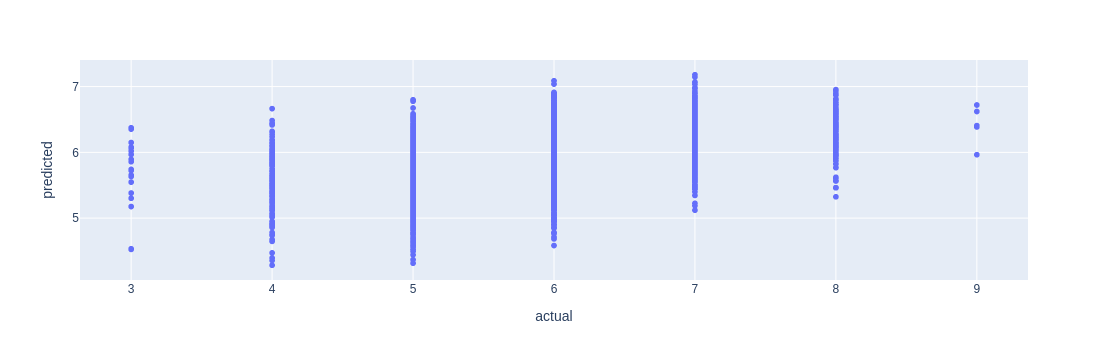

In [27]:
fig = px.scatter(predictions, x = 'actual', y = 'predicted')
fig.show()